# LDA Explanation Notebook


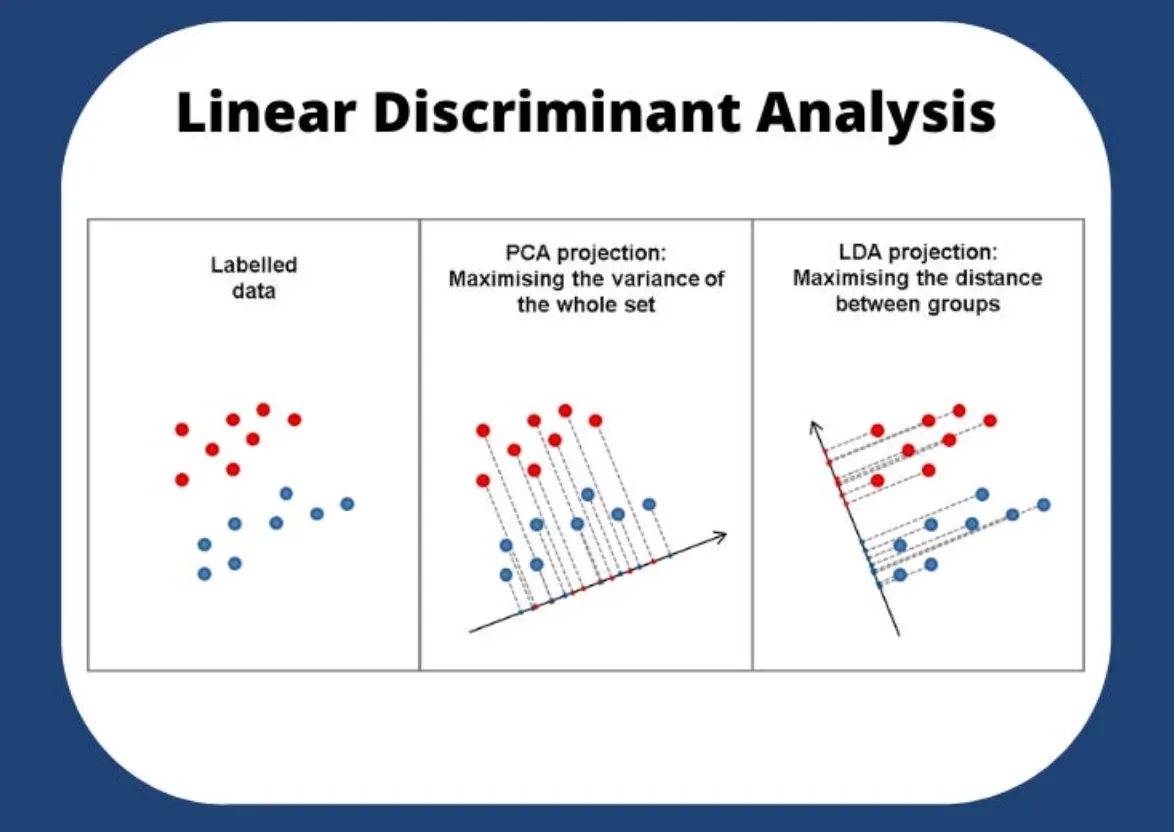

**هدف LDA چیست و چه تفاوتی با PCA دارد؟**
**چرا LDA برای داده‌های دارای لیبل مناسب است؟**
**LDA چگونه بهترین محور (یا محورها) را برای جداسازی کلاس‌ها پیدا می‌کند؟**


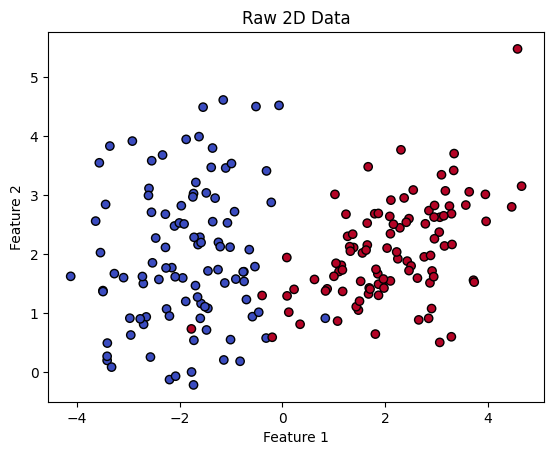

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_classification

# تولید یک دیتاست ۲بعدی قابل تفکیک
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

# رسم داده های خام
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title('Raw 2D Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

LDA به دنبال پیدا کردن یک محور (Feature جدید) است که **بیشترین جداسازی بین کلاس‌ها** و **کمترین پخش‌شدگی داخل کلاس‌ها** را ایجاد کند.

- PCA → بیشترین واریانس کل داده
- LDA → بیشترین جداسازی کلاس‌ها


In [3]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)


LDA با استفاده از معیار Fisher، نسبت زیر را بیشینه می‌کند:

$$
J = \frac{(\mu_1 - \mu_2)^2}{S_1 + S_2}
$$

- μ: میانگین کلاس‌ها روی محور جدید
- S: پخش‌شدگی داخل هر کلاس

LDA به دنبال محوری است که **میانگین کلاس‌ها دور** و **پراکنده‌گی هر کلاس کم** باشد.



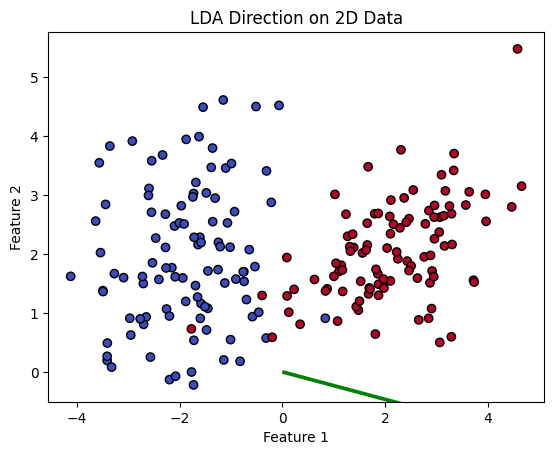

In [4]:
# رسم محور LDA روی نمودار دو بعدی
w = lda.coef_[0]  # بردار وزن LDA
# نرمال‌سازی برای رسم
w = w / np.linalg.norm(w)

plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.quiver(0, 0, w[0], w[1], scale=3, color='green')
plt.title('LDA Direction on 2D Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


### ** داده‌ها روی محور LDA چگونه توزیع می‌شوند؟**

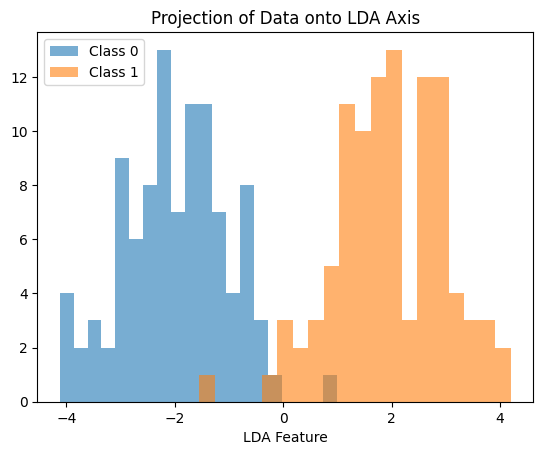

In [5]:
plt.hist(X_lda[y==0], bins=20, alpha=0.6, label='Class 0')
plt.hist(X_lda[y==1], bins=20, alpha=0.6, label='Class 1')
plt.title('Projection of Data onto LDA Axis')
plt.xlabel('LDA Feature')
plt.legend()
plt.show()

نتیجه:

- کلاس‌ها روی محور جدید فاصله‌ی بیشتری دارند.
- LDA توانسته جداسازی بهتری نسبت به ویژگی‌های خام ایجاد کند.

---

### ** مرزبندی LDA چگونه ساخته می‌شود؟**

در LDA، خط مرزبندی به صورت خطی ساخته می‌شود:

$$
w^T x + b = 0
$$

که w همان بردار LDA است.


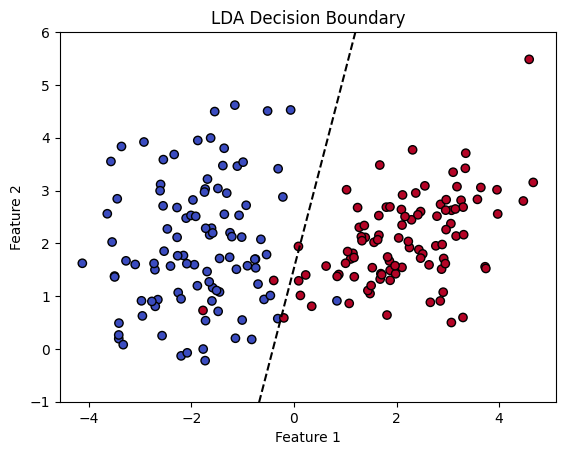

In [10]:
# محاسبه مرزبندی
coef = lda.coef_[0]
intercept = lda.intercept_

# رسم مرز تصمیم
xx = np.linspace(X[:,0].min(), X[:,0].max(), 200)
yy = -(coef[0]/coef[1])*xx - intercept/coef[1]

plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.plot(xx, yy, 'k--')
plt.title('LDA Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim((-1,6))
plt.show()